In [ ]:
pip install matplotlib transformers torch

Loading emotion detection model...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Reading and analyzing '/content/my_story.txt'...


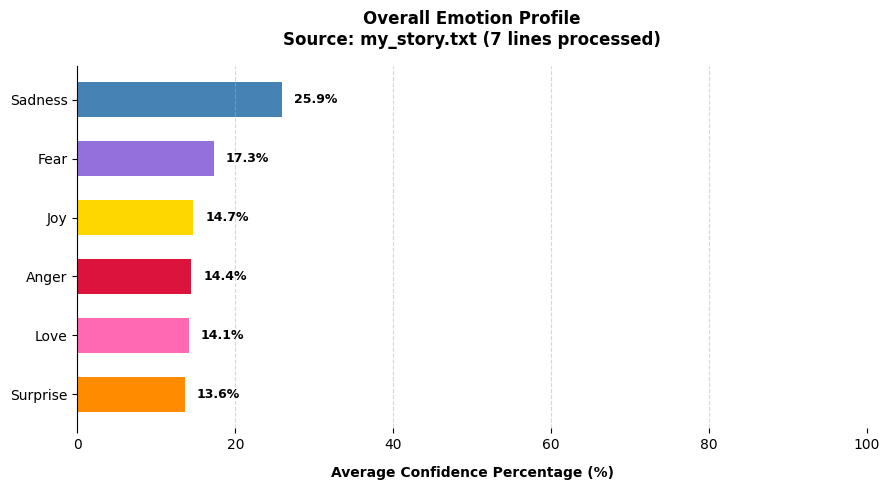

In [37]:
import os
import matplotlib.pyplot as plt
from transformers import pipeline

def create_emotion_classifier():
    """Initializes the emotion detection pipeline."""
    print("Loading emotion detection model...")
    return pipeline(
        "text-classification",
        model="bhadresh-savani/distilbert-base-uncased-emotion",
        top_k=None
    )

def analyze_text_file(file_path, classifier):
    """
    Reads a file line by line, calculates average emotional scores,
    and visualizes the total distribution.
    """
    if not os.path.exists(file_path):
        print(f"Error: The file '{file_path}' was not found.")
        return

    # Dictionary to keep track of the cumulative scores for each emotion
    cumulative_scores = {}
    valid_line_count = 0

    print(f"Reading and analyzing '{file_path}'...")

    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            clean_line = line.strip()
            # Skip empty lines
            if not clean_line:
                continue

            # Run the classifier on the individual line
            results = classifier(clean_line)[0]
            valid_line_count += 1

            # Accumulate scores
            for res in results:
                emotion = res['label'].capitalize()
                score = res['score']
                cumulative_scores[emotion] = cumulative_scores.get(emotion, 0.0) + score

    if valid_line_count == 0:
        print("The file was empty or contained no readable text lines.")
        return

    # Compute average scores and convert to percentages
    avg_percentages = {emo: (score / valid_line_count) * 100 for emo, score in cumulative_scores.items()}

    # Sort data by highest average percentage
    sorted_data = sorted(avg_percentages.items(), key=lambda x: x[1], reverse=True)
    emotions = [item[0] for item in sorted_data]
    percentages = [item[1] for item in sorted_data]

    # Map color scheme to sorted emotions
    emotion_colors = {
        'Joy': '#FFD700',      # Vibrant Gold
        'Love': '#FF69B4',     # Hot Pink
        'Surprise': '#FF8C00', # Bright Orange
        'Fear': '#9370DB',     # Medium Purple
        'Sadness': '#4682B4',  # Steel Blue
        'Anger': '#DC143C'     # Crimson Red
    }
    bar_colors = [emotion_colors.get(emo, '#A9A9A9') for emo in emotions]

    # Reverse for bottom-up drawing behavior in matplotlib
    emotions.reverse()
    percentages.reverse()
    bar_colors.reverse()

    # Create Plot
    plt.figure(figsize=(9, 5))
    bars = plt.barh(emotions, percentages, color=bar_colors, edgecolor='none', height=0.6)

    plt.xlim(0, 100)
    plt.xlabel("Average Confidence Percentage (%)", fontsize=10, fontweight='bold', labelpad=10)
    plt.title(f"Overall Emotion Profile\nSource: {os.path.basename(file_path)} ({valid_line_count} lines processed)", fontsize=12, pad=15, weight='bold')

    for spine in ['top', 'right', 'bottom']:
        plt.gca().spines[spine].set_visible(False)

    plt.grid(axis='x', linestyle='--', alpha=0.5)

    # Label bars
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width + 1.5,
            bar.get_y() + bar.get_height()/2,
            f'{width:.1f}%',
            va='center',
            ha='left',
            fontsize=9,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # --- Quick Setup for Testing ---
    # Creates a dummy file so you can run this script out-of-the-box
    target_file = "/content/my_story.txt"

    if not os.path.exists(target_file):
        print(f"Creating a sample file '{target_file}' for testing...")
        sample_content = """I woke up today feeling so excited because the sun was shining bright!
        But then I checked my email and found a scary message about my account security.
        It turned out to be a mistake, and I felt so incredibly relieved and happy.
        Still, the initial shock made me pretty angry at their system notification flow."""
        with open(target_file, 'w', encoding='utf-8') as f:
            f.write(sample_content.strip())
    # --------------------------------

    # 1. Start pipeline
    pipeline_instance = create_emotion_classifier()

    # 2. Run file analysis
    analyze_text_file(target_file, pipeline_instance)